## Data Exploration

In [97]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [44]:
titanic_data = pd.read_csv('train.csv')
pd.set_option('future.no_silent_downcasting', True)

In [45]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
print(f"rows {titanic_data.shape[0]}, columns {titanic_data.shape[1]}")

rows 891, columns 12


In [47]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [48]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Handling missing values 

In [49]:
#Drop the cabin column 
titanic_data = titanic_data.drop(columns=['Cabin'], axis=1)

In [50]:
# Replace missing values in age column with the mean value 
titanic_data = titanic_data.fillna(titanic_data['Age'].mean())

In [51]:
# to fill remove values in emabrked we will first find most repeated value and fill the missing value with it 
print(titanic_data['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [52]:
titanic_data = titanic_data.fillna(titanic_data['Embarked'].mode()[0])

In [53]:
titanic_data.isnull().sum() 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Missing values cleared/filled

In [54]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


# Plotting 
- To get familiar and pull out as many insights as we can 

In [55]:
# Survived and not survived passangers 
titanic_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

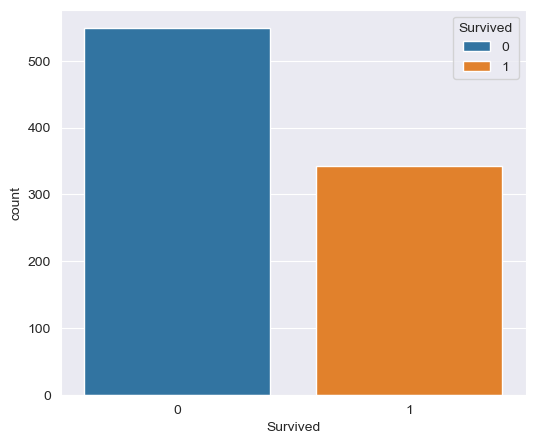

In [56]:
plt.figure(figsize=(6,5))
sns.set_style('darkgrid')
sns.countplot(titanic_data, x='Survived',hue='Survived')
plt.show()

In [57]:
# Number of males and females 
titanic_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

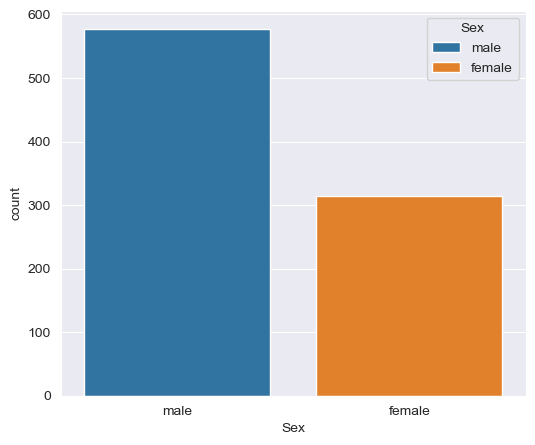

In [58]:
plt.figure(figsize=(6,5))
sns.set_style('darkgrid')
sns.countplot(titanic_data, x='Sex',hue='Sex',legend=True)
plt.show()

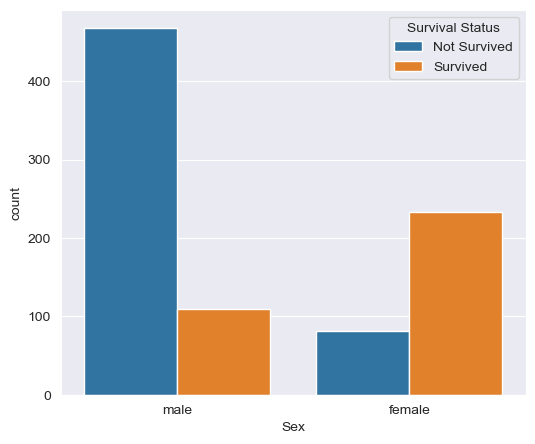

In [59]:
plt.figure(figsize=(6, 5))
sns.set_style('darkgrid')
ax = sns.countplot(data=titanic_data, x='Sex', hue='Survived', legend=True)
ax.legend(title='Survival Status', labels=['Not Survived', 'Survived'])
plt.show()

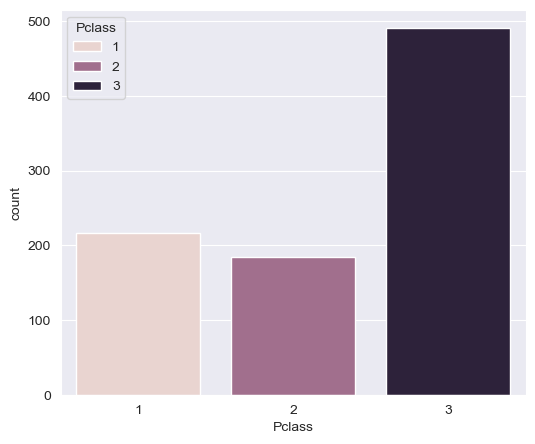

In [60]:
plt.figure(figsize=(6,5))
sns.set_style('darkgrid')
sns.countplot(titanic_data, x='Pclass',hue='Pclass',legend=True)
plt.show()

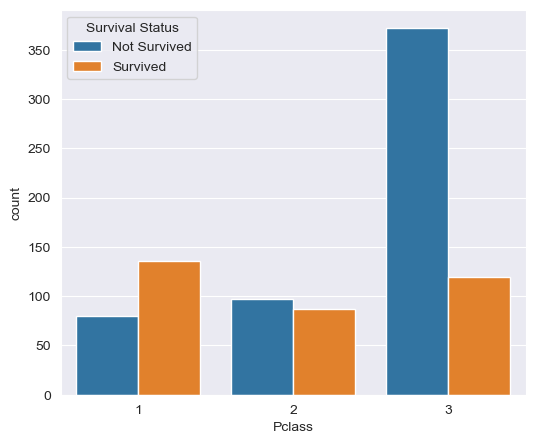

In [61]:
plt.figure(figsize=(6, 5))
sns.set_style('darkgrid')
ax = sns.countplot(data=titanic_data, x='Pclass', hue='Survived', legend=True)
ax.legend(title='Survival Status', labels=['Not Survived', 'Survived'])
plt.show()

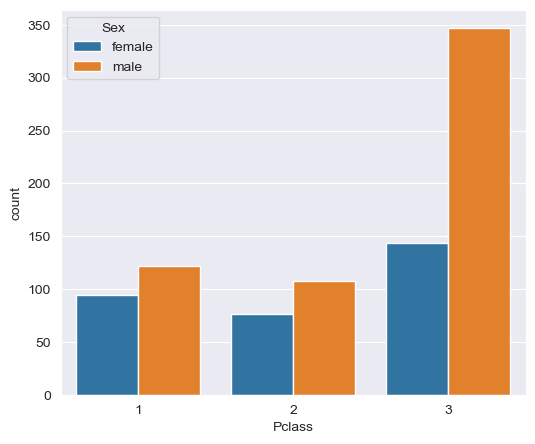

In [62]:
plt.figure(figsize=(6, 5))
sns.set_style('darkgrid')
ax = sns.countplot(data=titanic_data, x='Pclass', hue='Sex', legend=True)
plt.show()

## Encoding 

In [63]:
titanic_data.replace({
    'Sex': {'male': 1, 'female': 0},
    'Embarked': {'S': 0, 'C': 1, 'Q': 2}
}, inplace=True)

In [64]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0


## splitting data into features and targets

In [87]:
X = titanic_data.drop(columns=['PassengerId','Survived','Name','Ticket'],axis=1)
y = titanic_data['Survived']

In [66]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.000000,1,0,7.2500,0
1,1,0,38.000000,1,0,71.2833,1
2,3,0,26.000000,0,0,7.9250,0
3,1,0,35.000000,1,0,53.1000,0
4,3,1,35.000000,0,0,8.0500,0
...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,0
887,1,0,19.000000,0,0,30.0000,0
888,3,0,29.699118,1,2,23.4500,0
889,1,1,26.000000,0,0,30.0000,1


In [67]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [96]:
test_data = pd.read_csv('test.csv')

test_data.replace({
    'Sex': {'male': 1, 'female': 0},
    'Embarked': {'S': 0, 'C': 1, 'Q': 2}
}, inplace=True)

test_data = test_data.fillna(test_data['Age'].median())
test_data = test_data.fillna(test_data['Fare'].median())

X_test_final = test_data.drop(columns=['PassengerId','Name','Ticket','Cabin'])

### Train, test split  

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [69]:
print(X.shape,X_train.shape,X_test.shape)

(891, 7) (712, 7) (179, 7)


20% of data is awarded to test and rest 80% to train

## Model Training

### Logistic Regression

In [70]:
clf = LogisticRegression()

clf.fit(X_train,y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## Model Evaluation 

### Accuracy score 

In [71]:
# Accuracy score on Train data 
X_train_Pred = clf.predict(X_train)

In [101]:
# Compare prediction data with the y train to test the accuracy
training_data_accuracy_test = accuracy_score(y_train,X_train_Pred)

In [102]:
training_data_accuracy_train

0.8089887640449438

In [76]:
# Accuracy score on Test data 
X_test_Pred = clf.predict(X_test)

In [80]:
# Compare prediction data with the y test to test the accuracy
training_data_accuracy_test = accuracy_score(y_test,X_test_Pred)

In [81]:
training_data_accuracy_test

0.7821229050279329

In [98]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)

RandomForestClassifier(random_state=42)

In [99]:
train_preds = clf.predict(X)
print("Training Accuracy:", accuracy_score(y, train_preds))

Training Accuracy: 0.9820426487093153


In [105]:
test_preds = clf.predict(X_test_final)

In [106]:
submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv file created Successfully")

submission.csv file created Successfully
